# Customer Churn Analysis

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [14]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [15]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [16]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
df.dropna(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

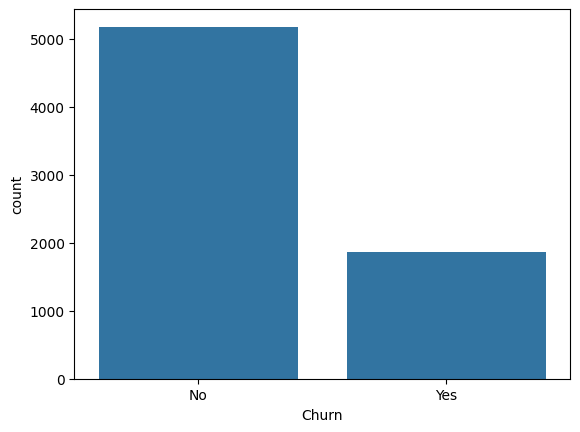

In [19]:
sns.countplot(x="Churn",data=df)
plt.show()

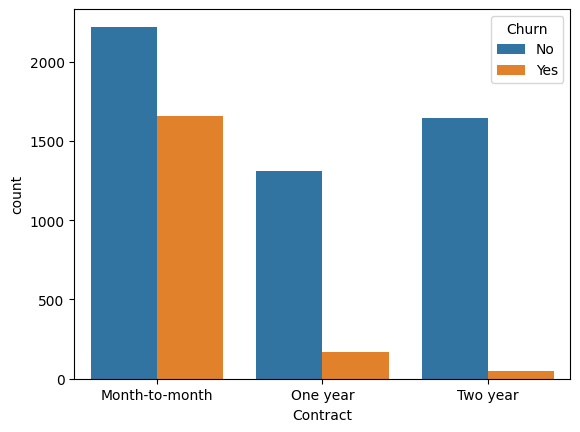

In [20]:
sns.countplot(x='Contract',hue='Churn',data=df)
plt.show()

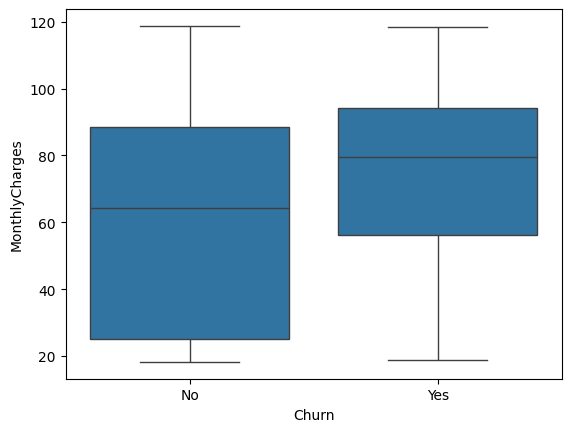

In [21]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.show()

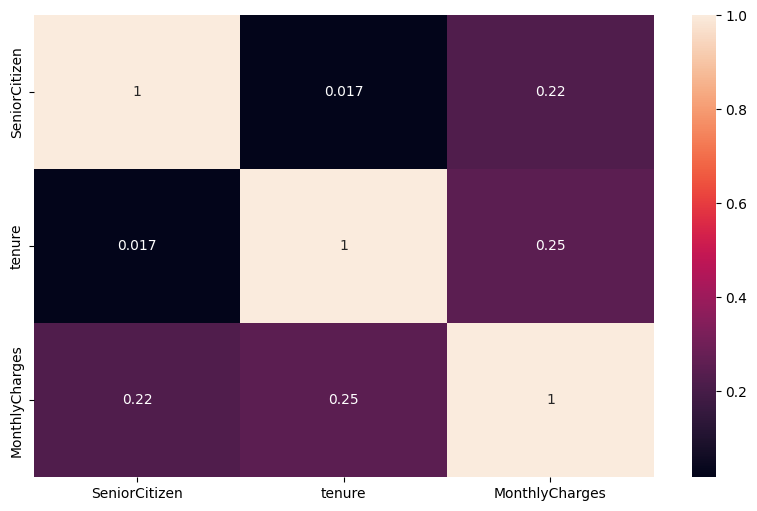

In [22]:
numeric_df=df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True)
plt.show()

In [23]:
df=pd.get_dummies(df,drop_first=True)

In [24]:
from re import X
from sklearn.model_selection import train_test_split

x= df.drop('Churn_Yes', axis=1)
y=df['Churn_Yes']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=100)
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [31]:
y_pred = model.predict(x_test)


In [33]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7672107877927609
[[851 185]
 [143 230]]
              precision    recall  f1-score   support

       False       0.86      0.82      0.84      1036
        True       0.55      0.62      0.58       373

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



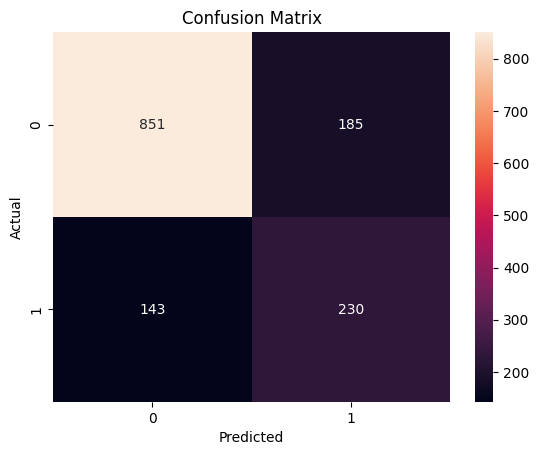

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

In [38]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, rf_pred)

0.8026969481902059

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

       False       0.82      0.93      0.87      1036
        True       0.70      0.45      0.55       373

    accuracy                           0.80      1409
   macro avg       0.76      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [41]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                             Feature  Importance
1                             tenure    0.100240
2                     MonthlyCharges    0.050477
7051     InternetService_Fiber optic    0.022292
7066               Contract_Two year    0.020809
7065               Contract_One year    0.019649
7054              OnlineSecurity_Yes    0.019463
7067            PaperlessBilling_Yes    0.016728
7069  PaymentMethod_Electronic check    0.015106
7060                 TechSupport_Yes    0.014275
7056                OnlineBackup_Yes    0.012630


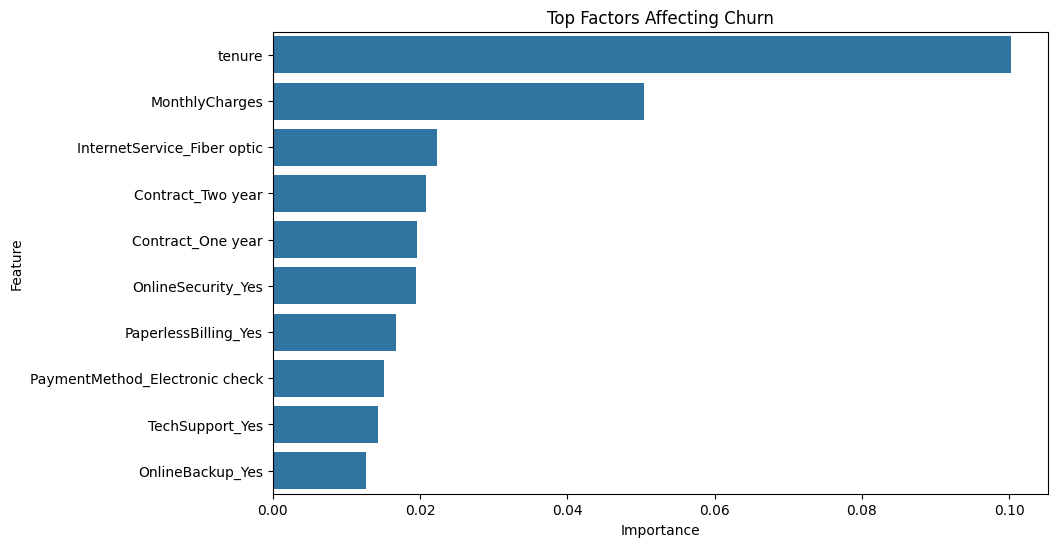

In [42]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top Factors Affecting Churn")
plt.show()

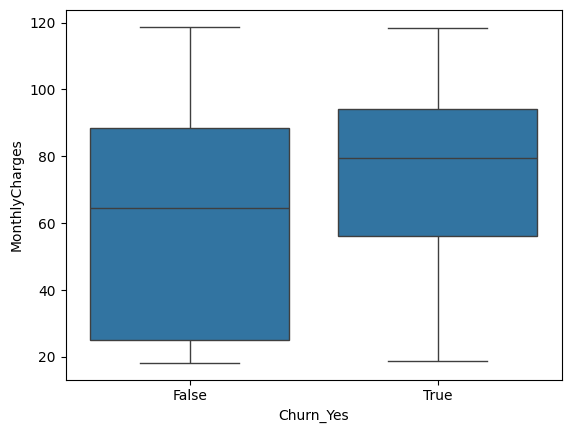

In [52]:
sns.boxplot(
    x="Churn_Yes",
    y="MonthlyCharges",
    data=df
)

plt.show()

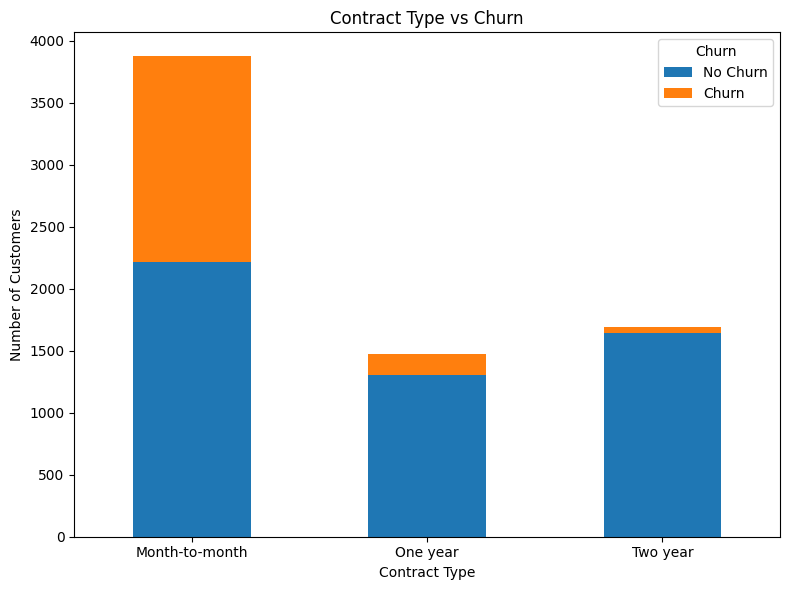

In [56]:
# Reconstruct 'Contract' and use 'Churn_Yes' from the dummified DataFrame for plotting
# Create a temporary DataFrame with relevant columns for reconstruction
temp_plot_df = df[['Contract_One year', 'Contract_Two year', 'Churn_Yes']].copy()

# Create a 'Contract_Type' column based on the dummy variables
def get_contract_type(row):
    if row['Contract_Two year'] == 1:
        return 'Two year'
    elif row['Contract_One year'] == 1:
        return 'One year'
    else:
        return 'Month-to-month' # This is the base category when drop_first=True

temp_plot_df['Contract_Type'] = temp_plot_df.apply(get_contract_type, axis=1)

# Now use the reconstructed 'Contract_Type' and 'Churn_Yes' for crosstab
contract_churn = pd.crosstab(
    temp_plot_df['Contract_Type'],
    temp_plot_df['Churn_Yes']
)

# Rename columns for clarity in plot legend
contract_churn.columns = ['No Churn', 'Churn']

contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6)
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()